In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn

In [ ]:
#  LOAD DATA
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
df = data.copy()

/tmp/ipykernel_884/127647589.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Fix column types
df.reset_index(inplace=True)

In [ ]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
1,2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2,2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
3,2015-01-07,23.864941,23.964608,23.632381,23.743124,160423600
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


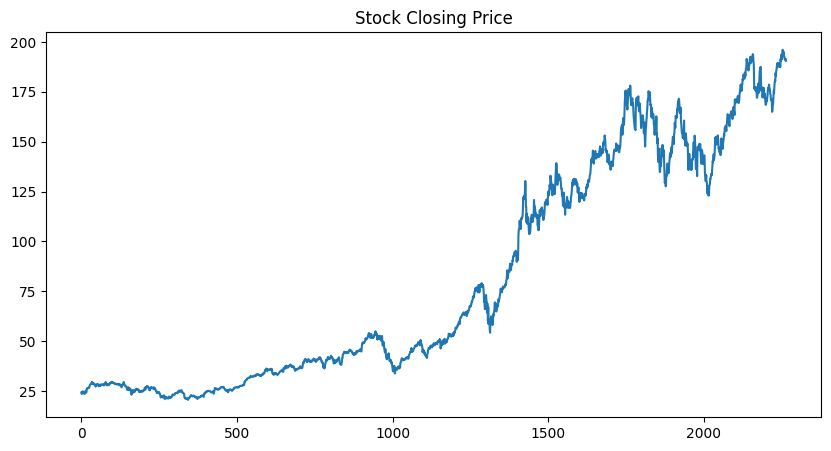

In [ ]:
# 3. EDA
# Closing price plot
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price")
plt.show()

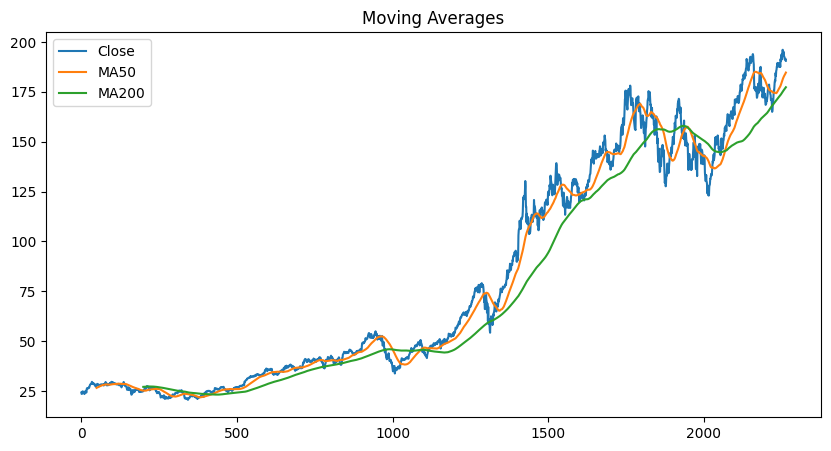

In [ ]:
# Moving averages
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA200'], label='MA200')
plt.legend()
plt.title("Moving Averages")
plt.show()

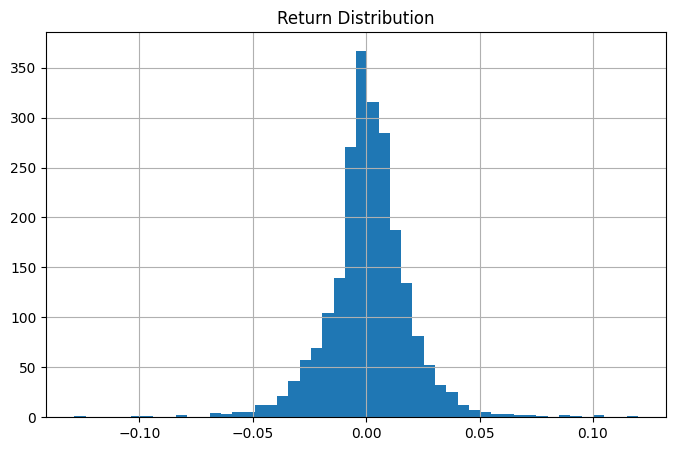

In [ ]:
# Daily returns
df['Return'] = df['Close'].pct_change()

plt.figure(figsize=(8,5))
df['Return'].hist(bins=50)
plt.title("Return Distribution")
plt.show()

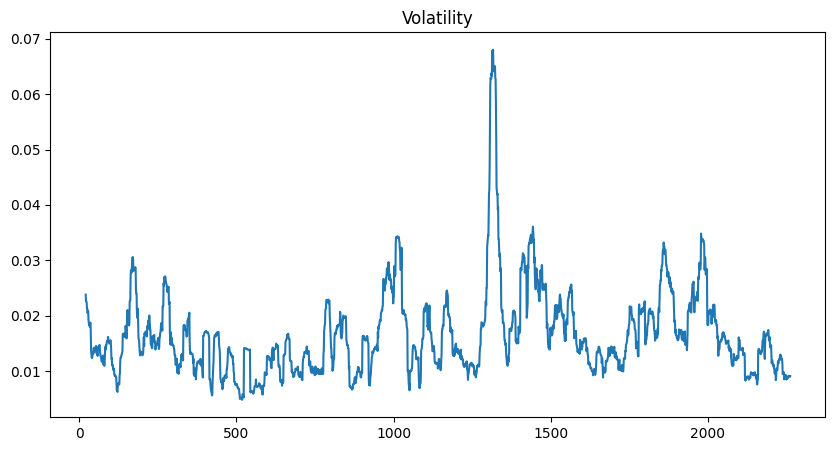

In [ ]:
# Volatility
df['Volatility'] = df['Return'].rolling(20).std()

plt.figure(figsize=(10,5))
plt.plot(df['Volatility'])
plt.title("Volatility")
plt.show()

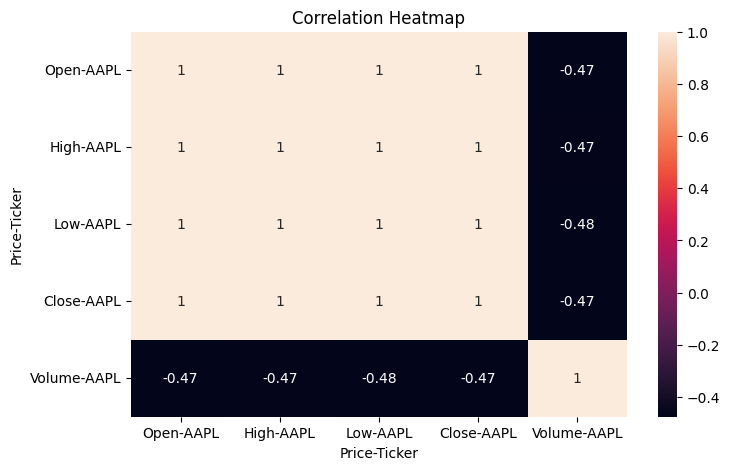

In [ ]:
# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# PREPROCESSING
data = df[['Close','Open','High','Low','Volume']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(data, seq_length=100):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0]) # Changed to predict only the 'Close' price (first column)
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, 100)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
#  MODELS
# LSTM
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])

In [ ]:
# Transformer
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_fc = nn.Linear(1, 32)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32,1)

    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        return self.fc(x[:,-1,:])

In [ ]:
# Hybrid
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1,64,batch_first=True)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(64,1)
        self.dropout = nn.Dropout(0.2)

    def forward(self,x):
        x,_ = self.lstm(x)
        x = self.transformer(x)
        return self.fc(x[:,-1,:])
        x = self.dropout(x)


In [ ]:
# 6. TRAINING FUNCTION
# ==============================
import torch.utils.data as data

def train_model(model, X_train, y_train, epochs=50, batch_size=64):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    # Create dataset and dataloader
    train_dataset = data.TensorDataset(X_train, y_train)
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch.unsqueeze(1)) # Ensure y_batch shape matches output

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"{model.__class__.__name__} Epoch {epoch+1}, Loss: {avg_loss}")

In [ ]:
#  TRAIN ALL MODELS
# Redefining models with correct input_size and fixing HybridModel dropout
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(5, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_fc = nn.Linear(5, 32)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32,1)

    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        return self.fc(x[:,-1,:])

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(5,64,batch_first=True)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(64,1)
        self.dropout = nn.Dropout(0.2)

    def forward(self,x):
        x,_ = self.lstm(x)
        x = self.transformer(x)
        x_last = self.dropout(x[:,-1,:]) # Apply dropout to the last time step output
        return self.fc(x_last)

lstm_model = LSTMModel()
transformer_model = TransformerModel()
hybrid_model = HybridModel()

train_model(lstm_model, X_train, y_train)
train_model(transformer_model, X_train, y_train)
train_model(hybrid_model, X_train, y_train)

LSTMModel Epoch 1, Loss: 0.06848205898755363
LSTMModel Epoch 2, Loss: 0.011870698516889076
LSTMModel Epoch 3, Loss: 0.0013474136191819394
LSTMModel Epoch 4, Loss: 0.0007331081703471552
LSTMModel Epoch 5, Loss: 0.00040567129118634123
LSTMModel Epoch 6, Loss: 0.0003007331210288352
LSTMModel Epoch 7, Loss: 0.00025308191626598794
LSTMModel Epoch 8, Loss: 0.00022648163141119376
LSTMModel Epoch 9, Loss: 0.00021469761233155232
LSTMModel Epoch 10, Loss: 0.00022246268518496696
LSTMModel Epoch 11, Loss: 0.00021288072356842998
LSTMModel Epoch 12, Loss: 0.0002167687330906379
LSTMModel Epoch 13, Loss: 0.00023017438434180804
LSTMModel Epoch 14, Loss: 0.00026092587307045633
LSTMModel Epoch 15, Loss: 0.0002825170080801139
LSTMModel Epoch 16, Loss: 0.00022025053554638622
LSTMModel Epoch 17, Loss: 0.00021420114223604157
LSTMModel Epoch 18, Loss: 0.00019761474024042918
LSTMModel Epoch 19, Loss: 0.00020482525308450152
LSTMModel Epoch 20, Loss: 0.00020630181955181927
LSTMModel Epoch 21, Loss: 0.00020227173

In [ ]:
# EVALUATION FUNCTION

def evaluate(model):
    model.eval()
    pred = model(X_test).detach().numpy()

    # Create dummy arrays for inverse transformation
    # Place the 1-feature prediction/actual into the 'Close' price column (index 0)
    dummy_pred = np.zeros((pred.shape[0], data_scaled.shape[1]))
    dummy_pred[:, 0] = pred.flatten() # Flatten pred to 1D before placing
    pred_original_scale = scaler.inverse_transform(dummy_pred)[:, 0] # Inverse transform and get only the 'Close' price

    dummy_actual = np.zeros((y_test.shape[0], data_scaled.shape[1]))
    dummy_actual[:, 0] = y_test.numpy().flatten() # Flatten y_test.numpy() to 1D before placing
    actual_original_scale = scaler.inverse_transform(dummy_actual)[:, 0]

    # Reshape back to 2D arrays (num_samples, 1) for consistent metric calculation
    pred = pred_original_scale.reshape(-1, 1)
    actual = actual_original_scale.reshape(-1, 1)

    mse = mean_squared_error(actual, pred)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, pred)

    return mse, mae, rmse, r2, pred, actual

In [ ]:
#  EVALUATE ALL MODELS
lstm_mse, lstm_mae, lstm_rmse, lstm_r2, lstm_pred, actual = evaluate(lstm_model)
trans_mse, trans_mae, trans_rmse, trans_r2, trans_pred, _ = evaluate(transformer_model)
hyb_mse, hyb_mae, hyb_rmse, hyb_r2, hyb_pred, _ = evaluate(hybrid_model)

In [ ]:
# COMPARISON TABLE
comparison = pd.DataFrame([
    ["LSTM", lstm_mse, lstm_mae, lstm_rmse, lstm_r2],
    ["Transformer", trans_mse, trans_mae, trans_rmse, trans_r2],
    ["Hybrid", hyb_mse, hyb_mae, hyb_rmse, hyb_r2]
], columns=["Model","MSE","MAE","RMSE","R2 Score"])

print(comparison)



         Model        MSE       MAE      RMSE  R2 Score
0         LSTM  20.855025  3.850079  4.566730  0.940913
1  Transformer  52.320964  6.061225  7.233323  0.851763
2       Hybrid  52.637867  6.085594  7.255196  0.850865


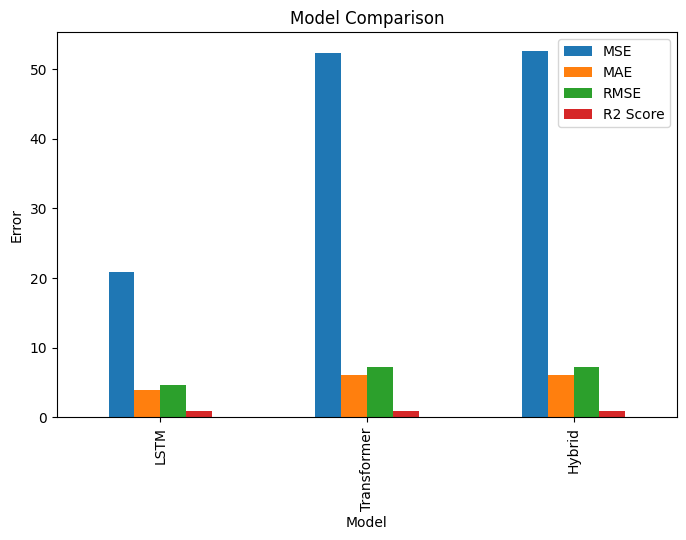

In [ ]:
 # VISUAL COMPARISON
comparison.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Error")
plt.show()

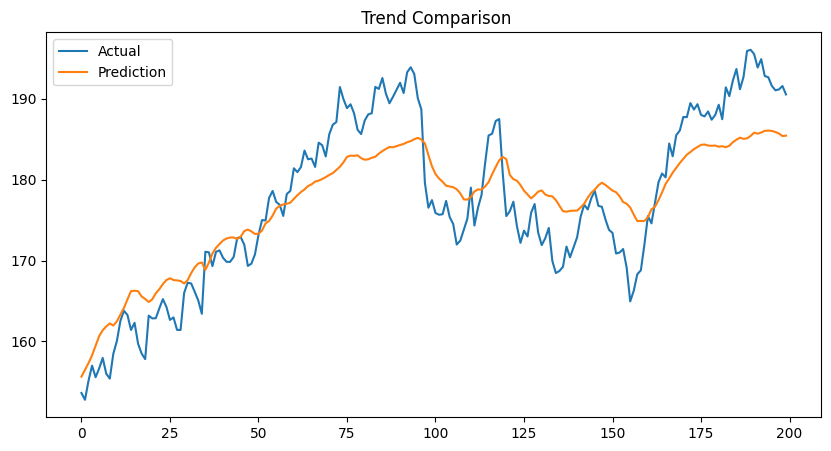

In [ ]:
# 12. ACTUAL VS PREDICTED
plt.figure(figsize=(10,5))
plt.plot(actual[-200:], label="Actual")
plt.plot(hyb_pred[-200:], label="Prediction")
plt.legend()
plt.title(" Trend Comparison")
plt.show()

In [ ]:
# NEXT DAY PREDICTION
test_input = X_test[-1].unsqueeze(0)
next_pred_scaled = hybrid_model(test_input).detach().numpy()

# Create a dummy array for inverse transformation
dummy_next_pred = np.zeros((next_pred_scaled.shape[0], data_scaled.shape[1]))
dummy_next_pred[:, 0] = next_pred_scaled.flatten() # Place the prediction into the 'Close' price column
next_pred_original_scale = scaler.inverse_transform(dummy_next_pred)[:, 0]

print("Next Day Predicted Price:", next_pred_original_scale[0])

Next Day Predicted Price: 185.45346104299745


In [ ]:
# SAVE BEST MODEL

import torch
import joblib

# Select best model based on RMSE
models = {
    "LSTM": (lstm_model, lstm_rmse),
    "Transformer": (transformer_model, trans_rmse),
    "Hybrid": (hybrid_model, hyb_rmse)
}

best_model_name = min(models, key=lambda x: models[x][1])
best_model = models[best_model_name][0]

print("Best Model Selected:", best_model_name)

# Save model weights (.pth)
torch.save(best_model.state_dict(), "best_model.pth")

# Save scaler
joblib.dump(scaler, "scaler.save")

print("Model and scaler saved successfully!")

Best Model Selected: LSTM
Model and scaler saved successfully!
